# 📝 Time Series - Machine Temperature

## 🌟 Highlights 
From this project "Time Series - Machine Temperature", the highlights with XGBoost classification are addressed as:
- Key technique: permutation importance analysis, parameter effect study, consisitency effect analysis, and threshold effect analysis
- Using permutation importance analysis indicates useful features for training. PR score increases from 0.28 to 0.51 for validation set
- PR score of 0.51 is mainly caused by data problem instead of overfitting
- Trained model (with training and validation set) can have 0.74 PR score at test set
- 0.51 precision for positive can be improved to 0.54 via consistency check and 0.65 via modified threshold (0.7)
- 0.67 f1 score for positive can be improved to 0.7 via consistency check and 0.78 via modified threshold (0.7)

## 🏭 Build Flow
- Import libraries
- Data cleaning & EDA
- Anomaly detection - XGBoost
  - Training/Validation/Test data split
  - Feature engineering
  - XGBoost classifier training/ fine tuning
  - XGBoost classifier prediction
  - XGBoost evaluation
  - Additional condition to reduce false alarm



### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from itertools import product

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

### Data cleaning & EDA
- Data collection frequency
- Data type correction
- Separate datetime for convinient filter
- Missing data
- Add label data into dataframe
- Visualization

In [2]:
file = r'D:\coding\2026\time_series_analysis\realKnownCause\realKnownCause\machine_temperature_system_failure.csv'

df = pd.read_csv(file)
df.head(10)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836
5,2013-12-02 21:40:00,78.710418
6,2013-12-02 21:45:00,80.269784
7,2013-12-02 21:50:00,80.272828
8,2013-12-02 21:55:00,80.353425
9,2013-12-02 22:00:00,79.486523


Data is collected every 5 mins

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


timestamp column is not datetime data type 

In [4]:
# Change timestamp to datetime
df['time'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value,time
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00


In [5]:
# Separate year, month, date, hour, min out to columns (convenient for filter purpose)
df['year'] = df['time'].apply(lambda x: x.year)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)
df['minute'] = df['time'].apply(lambda x: x.minute)
df

,timestamp,value,time,year,month,day,hour,minute
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35
...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  object        
 1   value      22695 non-null  float64       
 2   time       22695 non-null  datetime64[ns]
 3   year       22695 non-null  int64         
 4   month      22695 non-null  int64         
 5   day        22695 non-null  int64         
 6   hour       22695 non-null  int64         
 7   minute     22695 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 1.4+ MB


In [7]:
print(df.shape)
df['value'].isnull().value_counts()

(22695, 8)


False    22695
Name: value, dtype: int64

No missing data

#### Add label data into dataframe
- Add label (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json))
- Add label window (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_windows.json))

In [8]:
anomaly_label = [
        "2013-12-11 06:00:00",
        "2013-12-16 17:25:00",
        "2014-01-28 13:55:00",
        "2014-02-08 14:30:00"
]

anomaly_window = [
        [
            "2013-12-10 06:25:00.000000",
            "2013-12-12 05:35:00.000000"
        ],
        [
            "2013-12-15 17:50:00.000000",
            "2013-12-17 17:00:00.000000"
        ],
        [
            "2014-01-27 14:20:00.000000",
            "2014-01-29 13:30:00.000000"
        ],
        [
            "2014-02-07 14:55:00.000000",
            "2014-02-09 14:05:00.000000"
        ]
    ]

In [9]:
df['anomaly_point'] = 0
df['anomaly_window'] = 0

'''
anomaly_point:
    1: anomaly; 0: normal
anomaly_window:
    1: anomaly_window; 0: normal
'''

for i in anomaly_label:
    df.loc[df['time'] == i, 'anomaly_point'] = 1

for start, end in anomaly_window:
    df.loc[((df['time'] >= start) & (df['time'] <= end)), 'anomaly_window'] = 1

df.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Visualization
- Visualize anomaly points
- Visualize anamaly window

In [10]:
df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_points
df_anomaly_windows = df[df['anomaly_window'] == 1]
df_anomaly_windows

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
2126,2013-12-10 06:25:00,53.886196,2013-12-10 06:25:00,2013,12,10,6,25,0,1
2127,2013-12-10 06:30:00,54.113727,2013-12-10 06:30:00,2013,12,10,6,30,0,1
2128,2013-12-10 06:35:00,53.514577,2013-12-10 06:35:00,2013,12,10,6,35,0,1
2129,2013-12-10 06:40:00,54.920342,2013-12-10 06:40:00,2013,12,10,6,40,0,1
2130,2013-12-10 06:45:00,55.162629,2013-12-10 06:45:00,2013,12,10,6,45,0,1
...,...,...,...,...,...,...,...,...,...,...
19794,2014-02-09 13:45:00,91.330425,2014-02-09 13:45:00,2014,2,9,13,45,0,1
19795,2014-02-09 13:50:00,89.886941,2014-02-09 13:50:00,2014,2,9,13,50,0,1
19796,2014-02-09 13:55:00,88.997810,2014-02-09 13:55:00,2014,2,9,13,55,0,1
19797,2014-02-09 14:00:00,90.408573,2014-02-09 14:00:00,2014,2,9,14,0,0,1


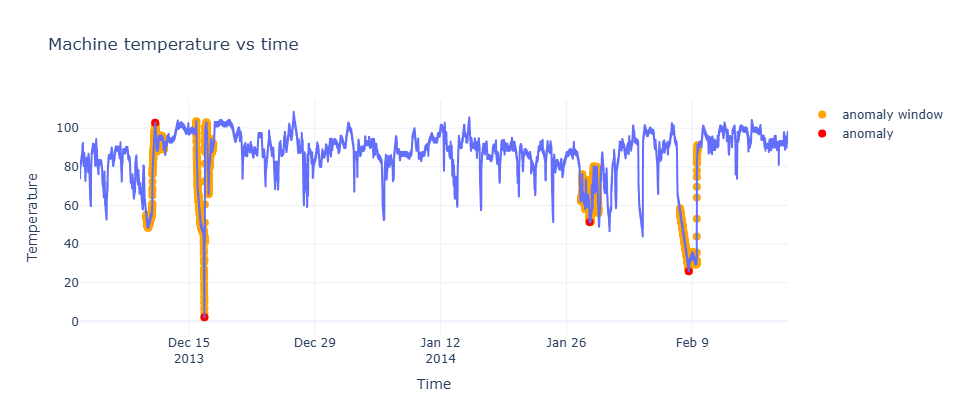

In [11]:
# Visualize line plot - temperature vs time
fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_windows = df[df['anomaly_window'] == 1]

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )


fig.show()

# '''
# This is the matplotlib version for reporting
# plt.figure(figsize=(16, 4.5))
# plt.plot(df['time'], df['value'])
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.xticks(fontsize=8)
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=6))
# plt.grid(True)
# plt.title('Machine temperature over time')
# plt.show()
# '''

Visualize anomalies and windows in the plot
- It is obvious to visually know 2nd and 4th as anomaly point; 1st and 3rd are less straightforward
- Window covers points before and after anomalies. Might be a hint of detection

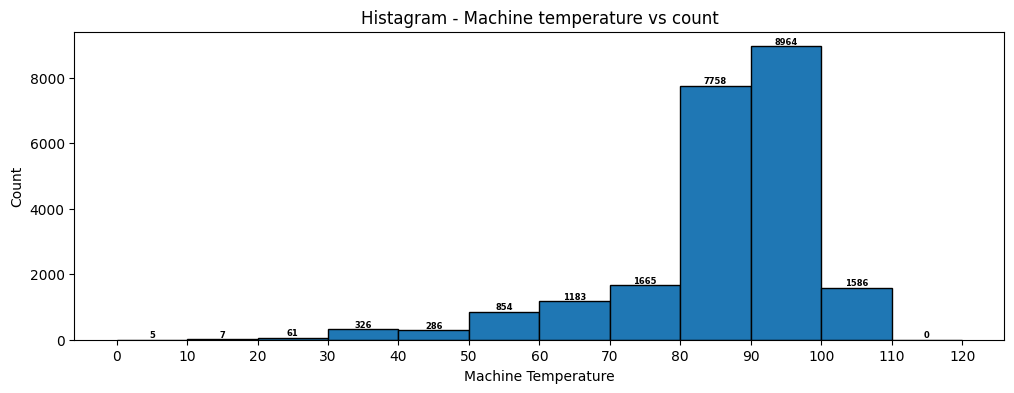

In [12]:
# Histagram
bin_size = range(0, 121, 10)
plt.figure(figsize=(12, 4))
value_count, baredge, bar = plt.hist(df['value'], bins=bin_size, edgecolor='black')

for c, edge, bar_ in zip(value_count, baredge, bar):
    plt.text(
        bar_.get_x() + bar_.get_width() / 2,
        bar_.get_height(),
        int(c),
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold',
        color='black',
    )
plt.xlabel('Machine Temperature')
plt.ylabel('Count')
plt.xticks(bin_size)
plt.title('Histagram - Machine temperature vs count')
plt.show()

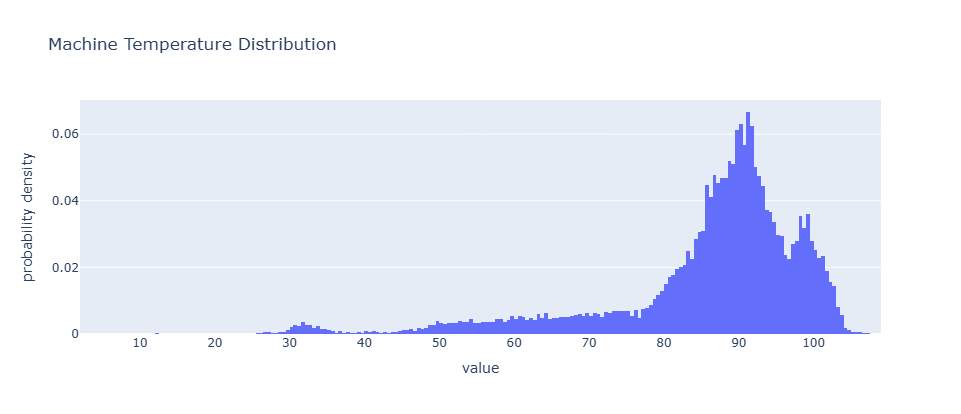

In [13]:
fig = px.histogram(df,
                   x='value', 
                   width=1000,
                   height=400,
                   histnorm="probability density",
                   title='Machine Temperature Distribution'
                  )
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(0, 121, 10)),
                )
fig.show()

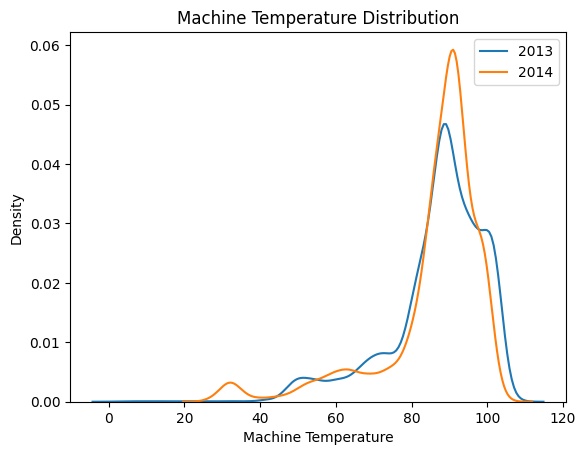

In [14]:
sns.kdeplot(df.loc[df['year']==2013, 'value'], label='2013')
sns.kdeplot(df.loc[df['year']==2014, 'value'], label='2014')

plt.xlabel('Machine Temperature')
plt.legend()
plt.title('Machine Temperature Distribution')
plt.show()

Majority of temperature is around 80~100 degree

### Anomaly Detection

#### XGBoost for classification

#### Function to use
- Temp value vs time
  - Raw temp vs time
  - Training/Validation/Test set visualization
  - Ground truth
  - Rolling properties 
- Confusion matrix
- Actual vs Prediction

#### XGBoost
- Training/Validation/Test data split
- Feature engineering
- XGBoost classifier training/ fine tuning
- XGBoost classifier prediction
- XGBoost evaluation
- Additional condition to reduce false alarm

#### Function to use

In [15]:
rolling_properties = [
    'Rolling_mean_one_hour',
    'Rolling_mean_six_hour',
    'Rolling_mean_twelve_hour',
    'Rolling_mean_one_day',
    'Rolling_std_one_hour',
    'Rolling_std_six_hour',
    'Rolling_std_twelve_hour',
    'Rolling_std_one_day',
    'Rolling_slope_one_hour',
    'Rolling_slope_six_hour',
    'Rolling_slope_twelve_hour', 
    'Rolling_slope_one_day'
]

def plot_xgb(df, plot_train_val_test=False, plot_ground_truth=False, plot_rolling=False):
    fig = go.Figure()

    # Plot raw temp vs time
    fig.add_trace(go.Scatter(x=df['time'], 
                             y=df['value'],
                             name='Actual value'
                            )
                 )

    # plot train/validation/test set
    if plot_train_val_test:
        fig.add_trace(go.Scatter(x=df_xgb_train['time'], 
                                 y=df_xgb_train['value'],
                                 # line=dict(color='green'),
                                 name='Training set'
                                )
                     )
        
        fig.add_trace(go.Scatter(x=df_xgb_val['time'], 
                                 y=df_xgb_val['value'],
                                 # line=dict(color='orange'),
                                 name='Validation set'
                                )
                     )
        fig.add_trace(go.Scatter(x=df_xgb_test['time'], 
                                 y=df_xgb_test['value'],
                                 # line=dict(color='orange'),
                                 name='Test set'
                                )
                     )     

    if plot_ground_truth:
        # Plot true anomaly window
        df_boosting_anomaly_window_true = df[df['anomaly_window'] == 1]
        fig.add_trace(go.Scatter(x=df_boosting_anomaly_window_true['time'],
                                 y=df_boosting_anomaly_window_true['value'],
                                 mode='markers',
                                 marker=dict(size=4,color='orange',symbol='circle'),
                                 name='Anomaly window'))
    
        # Plot true anomaly point
        df_boosting_anomaly_true = df[df['anomaly_point'] == 1]
        fig.add_trace(go.Scatter(x=df_boosting_anomaly_true['time'],
                                 y=df_boosting_anomaly_true['value'],
                                 mode='markers',
                                 marker=dict(size=4,color='red',symbol='circle'),
                                 name='Anomaly point'))

    if plot_rolling:
        for rolling in rolling_properties:
            fig.add_trace(go.Scatter(x=df['time'],
                                     y=df[rolling],
                                     name=rolling
                                    )
                         )
    
    fig.update_layout(template='simple_white',
                      font=dict(size=14),
                      xaxis_title='Time',
                      yaxis_title='Temperature',
                      width=1200,
                      height=400,
                      title='XGBoost - Anomaly detection')
    fig.show()

def plot_confusion_matrix(conf_matrix, mode):
    sns.heatmap(conf_matrix,
                cmap='Blues',
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=0.5
               )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    if mode in ['Train', 'Validation', 'Test']:
        plt.title(f'Confusion matrix - {mode}', size=10)
        plt.show()
    else:
        print('mode parameter should be Train/Validation/Test')
    

#### XGBoost - Training/Validation/Test data split
- Training set: 0~60% of data
- Validation set: 60~80% of data 
- Test set: 80~100% of data
- All contain normal and anonmaly

In [16]:
df_xgb_total = df.copy()
split_1 = int(0.6 * df.shape[0])
split_2 = int(0.8 * df.shape[0])
df_xgb_train = df_xgb_total.copy().iloc[:split_1]
df_xgb_val = df_xgb_total.copy().iloc[split_1:split_2]
df_xgb_train_val = df_xgb_total.copy().iloc[:split_2]
df_xgb_test = df_xgb_total.copy().iloc[split_2:]

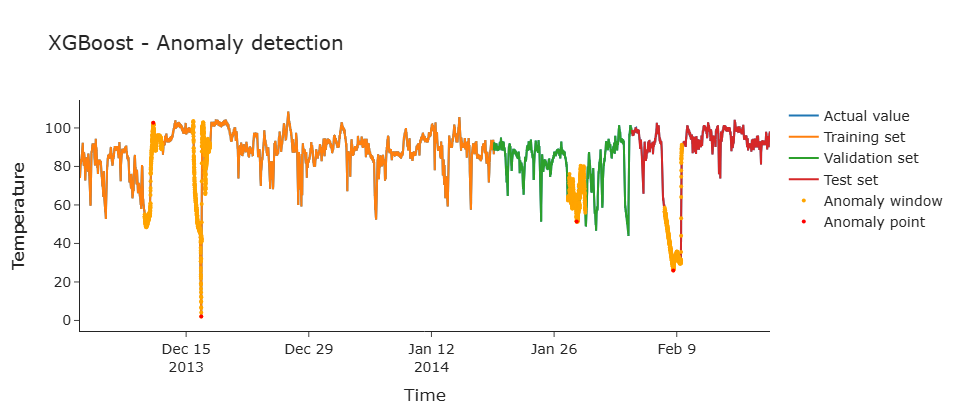

In [17]:
plot_xgb(df=df_xgb_total, plot_train_val_test=True, plot_ground_truth=True, plot_rolling=False)

#### XGBoost - Feature engineering

In [18]:
# Window choice (5 mins one point)
one_hour = 12
six_hour = 72
twelve_hour = 144
one_day = 288

windows = {
    'one_hour': 12, 
    'six_hour': 72,
    'twelve_hour': 144, 
    'one_day': 288
          }

df_list = [df_xgb_train, df_xgb_val, df_xgb_train_val, df_xgb_test]
# Rolling mean & std
for df in df_list:
    for window in windows:
        df[f'Rolling_mean_{window}'] = df['value'].rolling(windows[window]).mean()

# Rolling std
for df in df_list:
    for window in windows:
        df[f'Rolling_std_{window}'] = df['value'].rolling(windows[window]).std()

# Rolling slope
def slope(y):
    numerator = n * (x * y).sum() - x_sum * y.sum()
    denominator = n * x_square_sum - (x_sum ** 2)
    slope = numerator / denominator
    return slope

for df in df_list:
    for window in windows:
        x = np.arange(1, windows[window]+1)
        x_sum = x.sum()
        x_square_sum = (x ** 2).sum()
        n = len(x)
        df[f'Rolling_slope_{window}'] = df['value'].rolling(windows[window]).apply(slope)

#### XGBoost - XGBoost classifier training/ Fine tuning
  - Model training: Train model with all features from training set (without shuffle)
  - Build baseline: Use trained model to validate the performance (PR AUC score) with validation set (without shuffle)
  - Permutation importance analysis: Pick feature (one by one) and shuffle the value. Then, validate the performance to see which feature is useless
  - Final training: Train model with useful features with training and validation set

##### Model training

In [19]:
train_x = df_xgb_train[rolling_properties]
train_y = df_xgb_train['anomaly_window']

val_x = df_xgb_val[rolling_properties]
val_y = df_xgb_val['anomaly_window']

train_neg = df_xgb_train['anomaly_window'].value_counts()[0]
train_pos = df_xgb_train['anomaly_window'].value_counts()[1]

# Manual compute class weight
scale = train_neg / train_pos
print(scale)

# XGBoost classifier training
xgbclassifier = XGBClassifier(n_estimators=200, learning_rate=0.01, scale_pos_weight=scale, random_state=42)  # XGBClassifier does not have class_weight parameter. It use scale_pos_weight to indicate pos weight compared to neg weight
xgbclassifier.fit(train_x, train_y)

11.007936507936508


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

##### Build the baseline

PR score: 0.2819
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3972
           1       0.39      0.45      0.42       567

    accuracy                           0.84      4539
   macro avg       0.66      0.67      0.66      4539
weighted avg       0.85      0.84      0.85      4539



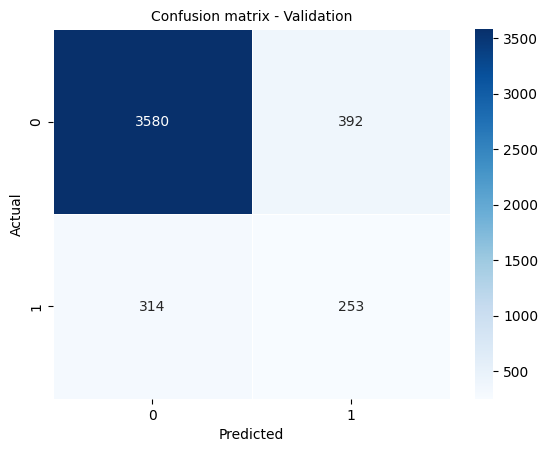

In [20]:
# Build the validation baseline
val_y_proba = xgbclassifier.predict_proba(val_x)
pr_score_val_baseline = average_precision_score(val_y, val_y_proba[:, 1])
print(f'PR score: {pr_score_val_baseline:.4f}')

val_y_pred = xgbclassifier.predict(val_x)
classification_report_xgb = classification_report(val_y, val_y_pred)
print(classification_report_xgb)

conf_xbg_val = confusion_matrix(val_y, val_y_pred)
plot_confusion_matrix(conf_xbg_val, mode='Validation')

##### Permutation importance analysis

In [21]:
# Permutation importance analysis
results = permutation_importance(xgbclassifier, val_x, val_y, n_repeats=10, scoring='average_precision', random_state=42)
for i in range(len(val_x.columns)):
    print(f'Feature: {val_x.columns[i]}')
    print(f'Importance score: {results.importances_mean[i]}')

Feature: Rolling_mean_one_hour
Importance score: -1.6990972478286848e-05
Feature: Rolling_mean_six_hour
Importance score: 0.09964314139543212
Feature: Rolling_mean_twelve_hour
Importance score: 0.0036069660949616276
Feature: Rolling_mean_one_day
Importance score: 0.0339042999520805
Feature: Rolling_std_one_hour
Importance score: 0.0016587479841273177
Feature: Rolling_std_six_hour
Importance score: 0.00043704638832746113
Feature: Rolling_std_twelve_hour
Importance score: -0.009941340390455406
Feature: Rolling_std_one_day
Importance score: -0.04791569329981269
Feature: Rolling_slope_one_hour
Importance score: 0.0006110190647436953
Feature: Rolling_slope_six_hour
Importance score: -0.0001355059879365461
Feature: Rolling_slope_twelve_hour
Importance score: 0.005447174612567463
Feature: Rolling_slope_one_day
Importance score: 0.0034706888916411884


Importances returns the drop between actual score (without shuffle) and score with shuffle.
- Higher positive: parameter is importance
- Almost zero: parameter is useless
- Negative: Parameter is misleading

From the above, we can see the important parameters are
- Rolling_mean_six_hour (~0.09 drop - critical)
- Rolling_mean_one_day (~0.03 drop - critical)
- Rolling_mean_twelve_hour (~0.003 drop - good to have)
- Rolling_slope_twelve_hour (~0.005 drop - good to have)
- Rolling_slope_one_day (~0.003 drop - good to have)  
- Les's modify the used features as above

In [22]:
used_features = ['Rolling_mean_six_hour', 'Rolling_mean_twelve_hour', 'Rolling_mean_one_day', 'Rolling_slope_twelve_hour', 'Rolling_slope_one_day']

# Fine tune model with useful features
train_x_tuned = df_xgb_train[used_features]
train_y = df_xgb_train['anomaly_window']

val_x_tuned = df_xgb_val[used_features]
val_y = df_xgb_val['anomaly_window']

train_neg = df_xgb_train['anomaly_window'].value_counts()[0]
train_pos = df_xgb_train['anomaly_window'].value_counts()[1]

# Manual compute class weight
scale = train_neg / train_pos
print(scale)

# XGBoost classifier training
xgbclassifier_tuned = XGBClassifier(n_estimators=200, learning_rate=0.01, scale_pos_weight=scale, random_state=42)  # XGBClassifier does not have class_weight parameter. It use scale_pos_weight to indicate pos weight compared to neg weight
xgbclassifier_tuned.fit(train_x_tuned, train_y)


11.007936507936508


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

PR score: 0.5156
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      3972
           1       0.35      0.65      0.46       567

    accuracy                           0.81      4539
   macro avg       0.65      0.74      0.67      4539
weighted avg       0.87      0.81      0.83      4539



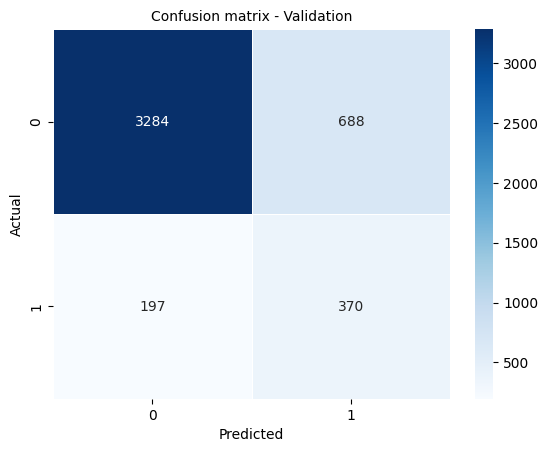

In [23]:
# Validate with validation set
val_y_proba_tuned = xgbclassifier_tuned.predict_proba(val_x_tuned)
pr_score_val_tuned = average_precision_score(val_y, val_y_proba_tuned[:, 1])
print(f'PR score: {pr_score_val_tuned:.4f}')

val_y_pred_tuned = xgbclassifier_tuned.predict(val_x_tuned)
classification_report_xgb_tuned = classification_report(val_y, val_y_pred_tuned)
print(classification_report_xgb_tuned)

conf_xbg_val_tuned = confusion_matrix(val_y, val_y_pred_tuned)
plot_confusion_matrix(conf_xbg_val_tuned, mode='Validation')

We can see the significant improvement at PR score from 0.28 to 0.51, meaning chosen features makes a good impact on prediction.  
However, 0.51 is just as good as randome guessing. Can we be better?

In [24]:
train_y_proba = xgbclassifier_tuned.predict_proba(train_x_tuned)
pr_score_train = average_precision_score(train_y, train_y_proba[:, 1])
print(f'Train PR score: {pr_score_train:.4f}')
print(f'Val PR score:   {pr_score_val_tuned:.4f}')

Train PR score: 0.9852
Val PR score:   0.5156


Noticed a big gap between train PR and val PR. Model performs really well at training set but bad in validation.  
This is the sign of overfitting.  
Let's give some regularization to see any improvement

##### Fine tuning the parameter

In [25]:
xgbclassifier_tuned_p = XGBClassifier(n_estimators=500,
                                      learning_rate=0.01,
                                      scale_pos_weight=scale,
                                      random_state=42,
                                      max_depth=3,  # Only allows 3-level depth
                                      subsample=0.8,  # Use 80% of data for tree training (force model to learn pattern with subset of data 
                                      colsample_bytree=0.8,
                                      min_child_weight=5,  # Minimum data count for leaf is 5
                                      early_stopping_rounds=20,
                                     )

xgbclassifier_tuned_p.fit(train_x_tuned, train_y,
                        eval_set=[(train_x_tuned, train_y), (val_x_tuned, val_y)],  # Display the validation result from both
                        verbose=True
                       )

val_y_proba_tuned_p = xgbclassifier_tuned_p.predict_proba(val_x_tuned)
pr_score_val_tuned_p = average_precision_score(val_y, val_y_proba_tuned_p[:, 1])

train_y_proba_tuned_p = xgbclassifier_tuned_p.predict_proba(train_x_tuned)
pr_score_train_tuned_p = average_precision_score(train_y, train_y_proba_tuned_p[:, 1])

print(f'Train PR score: {pr_score_train_tuned_p:.4f}')
print(f'Val PR score:   {pr_score_val_tuned_p:.4f}')

[0]	validation_0-logloss:0.68723	validation_1-logloss:0.68820
[1]	validation_0-logloss:0.68112	validation_1-logloss:0.68445
[2]	validation_0-logloss:0.67511	validation_1-logloss:0.68093
[3]	validation_0-logloss:0.66918	validation_1-logloss:0.67727
[4]	validation_0-logloss:0.66358	validation_1-logloss:0.67401
[5]	validation_0-logloss:0.65786	validation_1-logloss:0.67072
[6]	validation_0-logloss:0.65232	validation_1-logloss:0.66710
[7]	validation_0-logloss:0.64673	validation_1-logloss:0.66374
[8]	validation_0-logloss:0.64145	validation_1-logloss:0.66049
[9]	validation_0-logloss:0.63647	validation_1-logloss:0.65646
[10]	validation_0-logloss:0.63107	validation_1-logloss:0.65206
[11]	validation_0-logloss:0.62621	validation_1-logloss:0.64919
[12]	validation_0-logloss:0.62171	validation_1-logloss:0.64571
[13]	validation_0-logloss:0.61641	validation_1-logloss:0.64188
[14]	validation_0-logloss:0.61146	validation_1-logloss:0.63925
[15]	validation_0-logloss:0.60651	validation_1-logloss:0.63646
[1

With regularization technique, pr score is even worse between training and validation set.  
Looking at the data pattern, it seems a data issue as the anomaly pattern in training/validation set is different.  
So that is why model does not perform not as good as training set in validation set.  
Let's use model as is for final training

#### Final training

In [26]:
train_val_x = df_xgb_train_val[used_features]
train_val_y = df_xgb_train_val['anomaly_window']

test_x_tuned = df_xgb_test[used_features]
test_y = df_xgb_test['anomaly_window']

xgbclassifier_final = XGBClassifier(n_estimators=200, learning_rate=0.01, scale_pos_weight=scale, random_state=42)
xgbclassifier_final.fit(train_val_x, train_val_y,
                        eval_set=[(train_val_x, train_val_y), (test_x_tuned, test_y)],
                        verbose=True
                       )

[0]	validation_0-logloss:0.73807	validation_1-logloss:0.73616
[1]	validation_0-logloss:0.72868	validation_1-logloss:0.72885
[2]	validation_0-logloss:0.71950	validation_1-logloss:0.72171
[3]	validation_0-logloss:0.71050	validation_1-logloss:0.71473
[4]	validation_0-logloss:0.70170	validation_1-logloss:0.70793
[5]	validation_0-logloss:0.69307	validation_1-logloss:0.70128
[6]	validation_0-logloss:0.68462	validation_1-logloss:0.69478
[7]	validation_0-logloss:0.67633	validation_1-logloss:0.68841
[8]	validation_0-logloss:0.66821	validation_1-logloss:0.68218
[9]	validation_0-logloss:0.66025	validation_1-logloss:0.67607
[10]	validation_0-logloss:0.65244	validation_1-logloss:0.67010
[11]	validation_0-logloss:0.64478	validation_1-logloss:0.66424
[12]	validation_0-logloss:0.63727	validation_1-logloss:0.65851
[13]	validation_0-logloss:0.62994	validation_1-logloss:0.65287
[14]	validation_0-logloss:0.62270	validation_1-logloss:0.64737
[15]	validation_0-logloss:0.61563	validation_1-logloss:0.64195
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Logloss can go down continously. That is good

#### XGBoost - XGBoost classifier prediction

In [27]:
test_y_pred = xgbclassifier_final.predict(test_x_tuned)
test_y_proba = xgbclassifier_final.predict_proba(test_x_tuned)
df_xgb_test['Predicted anomaly'] = test_y_pred

#### XGBoost - XGBoost evaluation

PR score: 0.7436
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      3972
           1       0.51      0.99      0.67       567

    accuracy                           0.88      4539
   macro avg       0.75      0.93      0.80      4539
weighted avg       0.94      0.88      0.89      4539



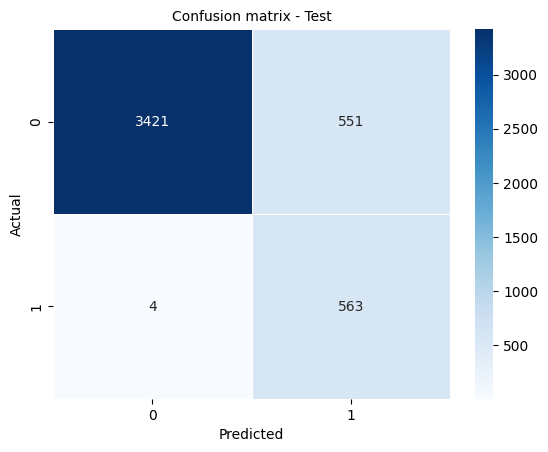

In [28]:
pr_score_test = average_precision_score(test_y, test_y_proba[:, 1])
print(f'PR score: {pr_score_test:.4f}')

classification_report_xgb_test = classification_report(test_y, test_y_pred)
print(classification_report_xgb_test)

conf_xbg_test = confusion_matrix(test_y, test_y_pred)
plot_confusion_matrix(conf_xbg_test, mode='Test')


Let's see how the prediction looks compared to ground truth for test period

In [29]:
def plot_test_actual_predicted(df, plot_rolling=False, consistency_check=False):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=df_xgb_total['time'], 
                             y=df_xgb_total['value'],
                             # line=dict(color='orange'),
                             name='Actual'
                            )
                 )
    
    # Plot true anomaly window
    df_anomaly_window_true_val = df_xgb_total[df_xgb_total['anomaly_window'] == 1]
    fig.add_trace(go.Scatter(x=df_anomaly_window_true_val['time'],
                             y=df_anomaly_window_true_val['value'],
                             mode='markers',
                             marker=dict(size=4,color='orange',symbol='circle'),
                             name='Anomaly window'))
    
    # Plot true anomaly point
    df_anomaly_true_val = df_xgb_total[df_xgb_total['anomaly_point'] == 1]
    fig.add_trace(go.Scatter(x=df_anomaly_true_val['time'],
                             y=df_anomaly_true_val['value'],
                             mode='markers',
                             marker=dict(size=4,color='red',symbol='circle'),
                             name='Anomaly point'))
    
    # Plot predicted anomaly points
    df_xgb_test_pred = df[df['Predicted anomaly']==1]

    fig.add_trace(go.Scatter(x=df_xgb_test_pred['time'],
                             y=df_xgb_test_pred['value'],
                             mode='markers',
                             marker=dict(size=4,color='green',symbol='circle'),
                             name='Predicted anomaly point'))

    if plot_rolling:
        for rolling in used_features:
            fig.add_trace(go.Scatter(x=df['time'],
                                     y=df[rolling],
                                     name=rolling
                                    )
                         )    
    
    if consistency_check==True:
        df_xgb_test_consistency_ = df_xgb_test_consistency[df_xgb_test_consistency['Consistency result - one hour']==1]
        fig.add_trace(go.Scatter(x=df_xgb_test_consistency_['time'],
                                 y=df_xgb_test_consistency_['value'],
                                 mode='markers',
                                 marker=dict(size=4,color='black',symbol='circle'),
                                 name='Predicted anomaly point - Consistency (1 hour)'))        
    
    fig.update_layout(template='simple_white',
                      font=dict(size=14),
                      xaxis_title='Time',
                      yaxis_title='Temperature',
                      width=1200,
                      height=400,
                      title='Test set - Actual vs Prediction')
    fig.show()

In [30]:
plot_test_actual_predicted(df_xgb_test)

PR score is 0.74, which is better than random guessing.  
It almost flags all ground truth anomalies.  
We Still have 51% precision, indicatinng some FP.  
Let's improve with additional condition

#### XGBoost - Additional condition to reduce false alarm
- Add consistency check: Only flag when detecting continuous anomaly detection
- Change positive threshold: Only flag when positive probability is higher than threshold (default: 0.5)

##### Consistency check
- Only flag anomaly when there is continuous flagging over 1 hour

In [31]:
df_xgb_test_consistency = df_xgb_test.copy()

In [32]:
# Add consistency for anomaly detection. Flag anomaly if continuous 1-hour anomaly

df_xgb_test_consistency['Consistency result - one hour'] = df_xgb_test_consistency['Predicted anomaly'].rolling(windows['one_hour']).mean().apply(lambda x: 1 if x == 1 else 0 if x != 1 else x)

In [33]:
plot_test_actual_predicted(df_xgb_test_consistency, consistency_check=True)

In [35]:
# pr_score_test = average_precision_score(test_y, df_xgb_test_consistency['Consistency result - one hour'])
# print(f'PR score: {pr_score_test:.4f}')

PR score: 0.5338


              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3972
           1       0.54      0.97      0.70       567

    accuracy                           0.90      4539
   macro avg       0.77      0.93      0.82      4539
weighted avg       0.94      0.90      0.91      4539



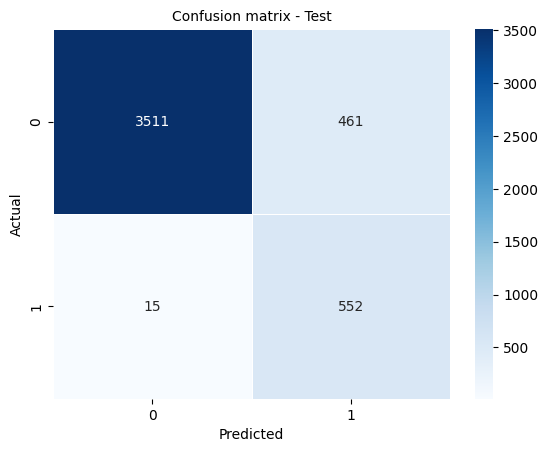

In [36]:
classification_report_xgb_test_consistency = classification_report(test_y, df_xgb_test_consistency['Consistency result - one hour'])
print(classification_report_xgb_test_consistency)

conf_xbg_test_consistency = confusion_matrix(test_y, df_xgb_test_consistency['Consistency result - one hour'])
plot_confusion_matrix(conf_xbg_test_consistency, mode='Test')

The precision increases to 0.54 from 0.51 and f1 score increases to 0.7 from 0.67

##### Change positive threshold
- Use 0.7 as positive threshold --> Only flag as anomaly when probability is higher than 0.7

In [38]:
df_xgb_test_threshold = df_xgb_test.copy().drop(['Predicted anomaly'], axis=1)

In [39]:
df_xgb_test_threshold['Predicted anomaly'] = np.where(test_y_proba[:, 1] >= 0.7, 1, 0)  # Use 0.7 as positive threshold
df_xgb_test_threshold['Predicted probability'] = test_y_proba[:, 1]

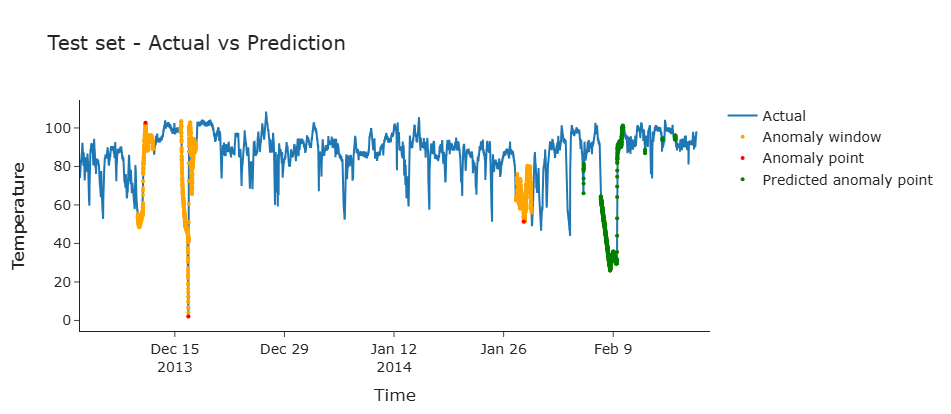

In [40]:
plot_test_actual_predicted(df_xgb_test_threshold)

In [41]:
# pr_score_test = average_precision_score(test_y, df_xgb_test_threshold['Predicted anomaly'])
# print(f'PR score: {pr_score_test:.4f}')

PR score: 0.6373


              precision    recall  f1-score   support

           0       1.00      0.92      0.96      3972
           1       0.65      0.98      0.78       567

    accuracy                           0.93      4539
   macro avg       0.82      0.95      0.87      4539
weighted avg       0.95      0.93      0.94      4539



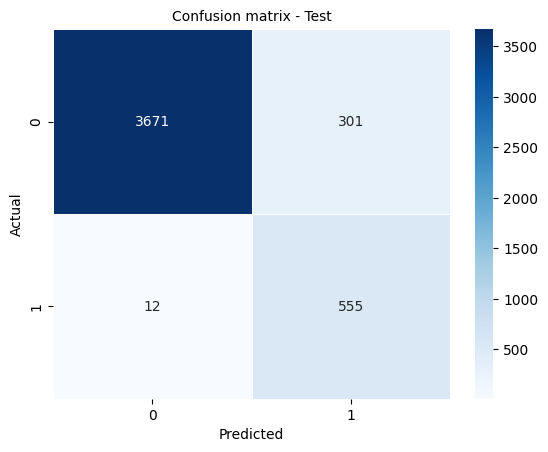

In [42]:
classification_report_xgb_test_threshold = classification_report(test_y, df_xgb_test_threshold['Predicted anomaly'])
print(classification_report_xgb_test_threshold)

conf_xbg_test_threshold = confusion_matrix(test_y, df_xgb_test_threshold['Predicted anomaly'])
plot_confusion_matrix(conf_xbg_test_threshold, mode='Test')

The precision increases to 0.65 from 0.51 and f1 score increases to 0.78 from 0.67